# Fintech Transactions EDA
EDA using `pandas`, `matplotlib`, and `seaborn`.

In [39]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# plotting defaults
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [40]:
# Load transactions.csv
# Adjust `csv_path` if your CSV is located elsewhere in the repo
csv_path = "../data/raw/transactions.csv"
transactions = pd.read_csv(csv_path, parse_dates=["transaction_time"])
print("Loaded rows,cols:", transactions.shape)

Loaded rows,cols: (10000, 8)


In [41]:
# Display dataset overview
print("First 5 rows:")
display(transactions.head())
print("\nDtypes:")
print(transactions.dtypes)
print("\nColumns:")
print(list(transactions.columns))

First 5 rows:


,transaction_id,customer_id,merchant_id,amount,transaction_time,payment_method,transaction_status,fraud_flag
0,1,13,6,62.38,2026-02-09 00:45:07,credit_card,pending,False
1,2,454,81,40.16,2026-05-18 02:02:50,digital_wallet,settled,False
2,3,336,89,5365.84,2026-03-02 20:48:05,credit_card,pending,False
3,4,113,23,98.31,2025-07-15 02:50:10,buy_now_pay_later,settled,False
4,5,435,16,36.80,2026-04-19 21:32:53,buy_now_pay_later,settled,False



Dtypes:
transaction_id                 int64
customer_id                    int64
merchant_id                    int64
amount                       float64
transaction_time      datetime64[ns]
payment_method                object
transaction_status            object
fraud_flag                      bool
dtype: object

Columns:
['transaction_id', 'customer_id', 'merchant_id', 'amount', 'transaction_time', 'payment_method', 'transaction_status', 'fraud_flag']


In [42]:
# Check null values
missing = transactions.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(transactions) * 100).round(2)
display(missing)

,missing_count,missing_pct
transaction_id,0,0.0
customer_id,0,0.0
merchant_id,0,0.0
amount,0,0.0
transaction_time,0,0.0
payment_method,0,0.0
transaction_status,0,0.0
fraud_flag,0,0.0


In [43]:
# Basic statistics summary
# Numeric summary for `amount`
if "amount" in transactions.columns:
    display(transactions[["amount"]].describe().T)

# Key categorical counts for quick sanity
for col in ["transaction_status", "payment_method", "fraud_flag"]:
    if col in transactions.columns:
        print(f"\nValue counts for {col}:")
        print(transactions[col].value_counts(dropna=False).head(10))

,count,mean,std,min,25%,50%,75%,max
amount,10000.0,591.614988,1471.966121,1.25,33.0475,70.61,207.9325,9797.85



Value counts for transaction_status:
transaction_status
settled       7120
pending       1432
failed         854
refunded       395
chargeback     199
Name: count, dtype: int64

Value counts for payment_method:
payment_method
bank_transfer        2055
buy_now_pay_later    2039
digital_wallet       2028
debit_card           1957
credit_card          1921
Name: count, dtype: int64

Value counts for fraud_flag:
fraud_flag
False    9373
True      627
Name: count, dtype: int64


,month,transaction_count,total_value
0,2025-05-01,306,173713.40
1,2025-06-01,586,339183.90
2,2025-07-01,600,456683.73
3,2025-08-01,611,303889.83
4,2025-09-01,559,296842.24


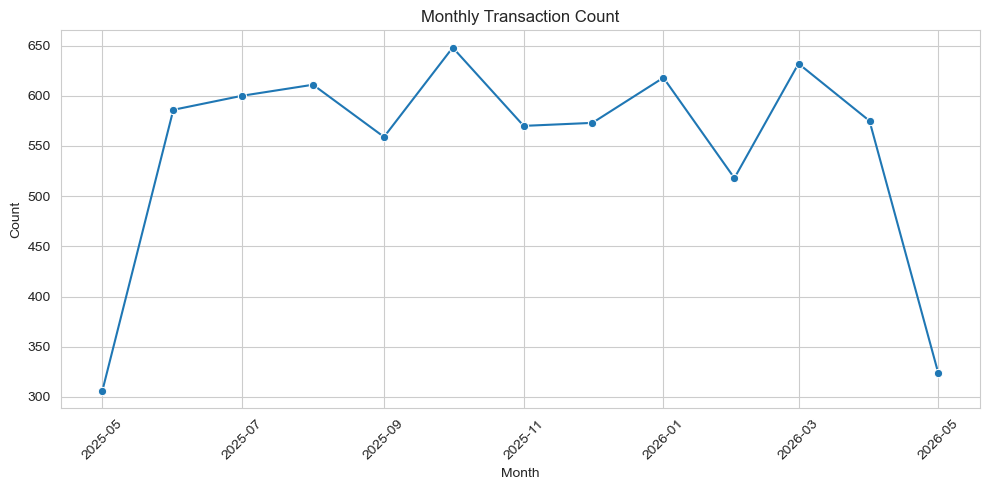

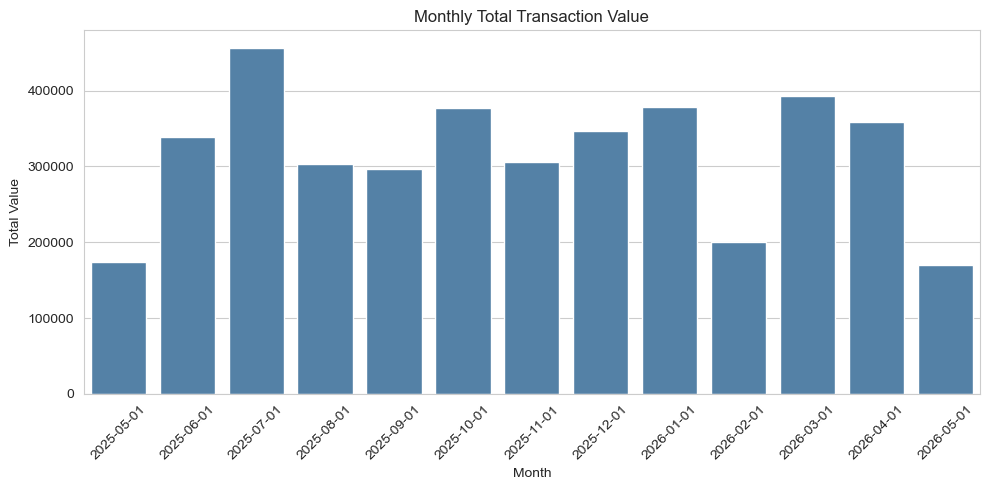

In [44]:
# Monthly transaction trend analysis (aggregation + plots)
# Create a month column (first day of the month)
transactions["month"] = transactions["transaction_time"].dt.to_period("M").dt.to_timestamp()

# Use completed transactions when available (common in payments datasets)
if "transaction_status" in transactions.columns:
    df_completed = transactions[transactions["transaction_status"] == "settled"].copy()
else:
    df_completed = transactions.copy()

monthly = (
    df_completed.groupby("month")
    .agg(transaction_count=("transaction_id", "size"), total_value=("amount", "sum"))
    .sort_index()
    .reset_index()
)

display(monthly.head())

# Line chart: monthly transaction count
plt.figure()
sns.lineplot(data=monthly, x="month", y="transaction_count", marker="o")
plt.title("Monthly Transaction Count")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar chart: monthly total value
plt.figure()
sns.barplot(data=monthly, x="month", y="total_value", color="steelblue")
plt.title("Monthly Total Transaction Value")
plt.xlabel("Month")
plt.ylabel("Total Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,fraud_flag,count
0,False,9373
1,True,627


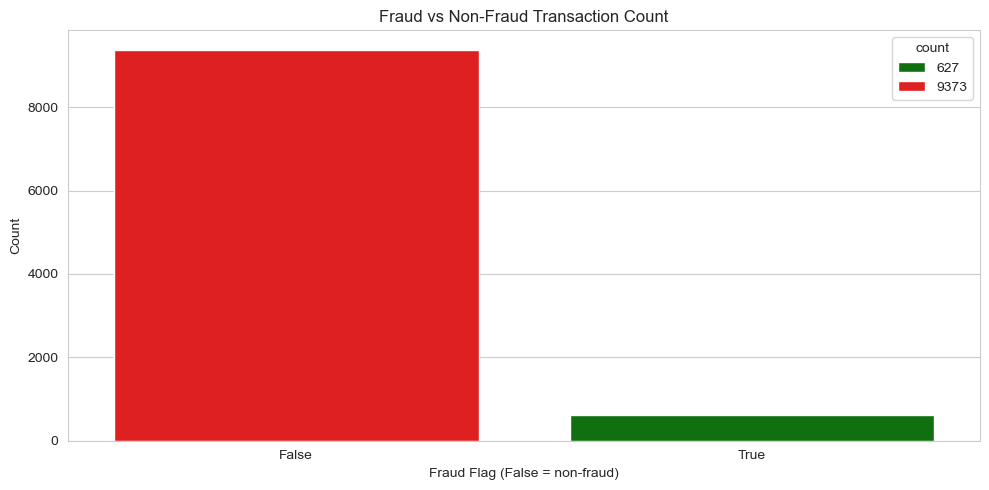

In [45]:
# Fraud vs Non-Fraud transaction count (simple counts + plot)
if "fraud_flag" in transactions.columns:
    fraud_counts = transactions["fraud_flag"].fillna(False).value_counts().rename_axis("fraud_flag").reset_index(name="count")
    display(fraud_counts)
    plt.figure()
    sns.barplot(data=fraud_counts, x="fraud_flag", y="count", hue="count", palette=["green", "red"])
    plt.title("Fraud vs Non-Fraud Transaction Count")
    plt.xlabel("Fraud Flag (False = non-fraud)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No `fraud_flag` column found; skipping fraud chart.")

,payment_method,transaction_count,total_value,share_pct
0,debit_card,1400,846848.25,20.65
1,digital_wallet,1425,837472.01,20.43
2,bank_transfer,1476,817999.29,19.95
3,buy_now_pay_later,1436,815945.72,19.90
4,credit_card,1383,781948.92,19.07


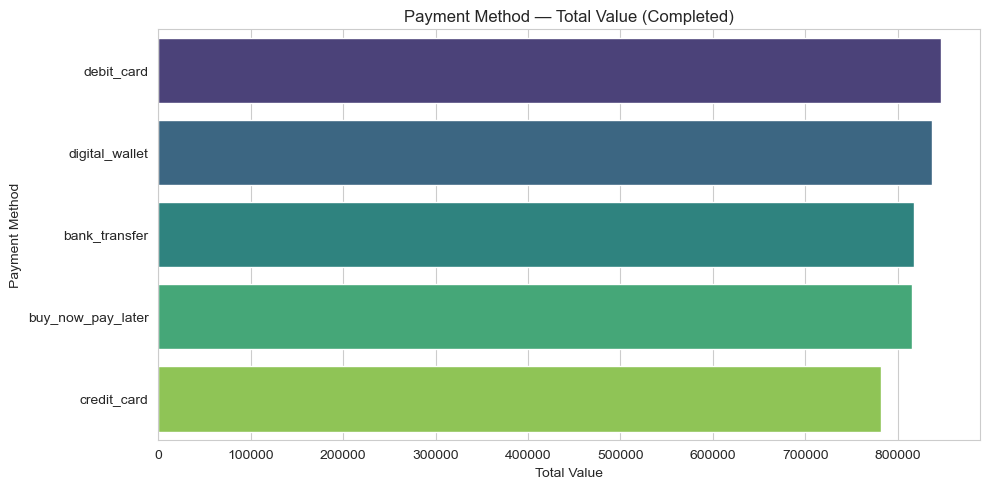

In [46]:
# Payment method distribution (counts, value, and share)
if "payment_method" in df_completed.columns:
    pay_dist = (
        df_completed.groupby("payment_method")
        .agg(transaction_count=("transaction_id", "size"), total_value=("amount", "sum"))
        .sort_values("total_value", ascending=False)
        .reset_index()
    )
    pay_dist["share_pct"] = (pay_dist["total_value"] / pay_dist["total_value"].sum() * 100).round(2)
    display(pay_dist.head(10))

    plt.figure()
    sns.barplot(data=pay_dist, x="total_value", y="payment_method",  hue="payment_method", palette="viridis")
    plt.title("Payment Method — Total Value (Completed)")
    plt.xlabel("Total Value")
    plt.ylabel("Payment Method")
    plt.tight_layout()
    plt.show()
else:
    print("No `payment_method` column found; skipping payment distribution.")

,customer_id,total_spent,tx_count,customer_id_str
0,347,32461.55,15,347
1,275,31694.02,21,275
2,451,30906.68,14,451
3,413,28215.06,18,413
4,170,26959.55,17,170
5,71,24222.88,16,71
6,91,23533.72,22,91
7,294,23527.25,21,294
8,380,22805.59,20,380
9,282,22642.34,13,282


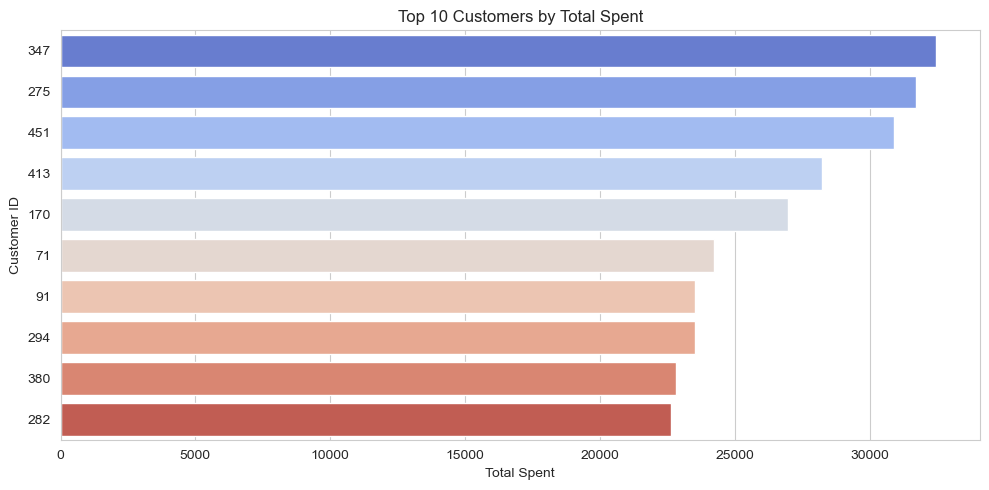

In [47]:
# Top 10 customers by total transaction amount
if "customer_id" in df_completed.columns:
    top_customers = (
        df_completed.groupby("customer_id")
        .agg(total_spent=("amount", "sum"), tx_count=("transaction_id", "size"))
        .sort_values("total_spent", ascending=False)
        .reset_index()
        .head(10)
    )
    top_customers["customer_id_str"] = top_customers["customer_id"].astype(str)
    display(top_customers)

    plt.figure()
    sns.barplot(data=top_customers, x="total_spent", y="customer_id_str", hue="customer_id_str", palette="coolwarm")
    plt.title("Top 10 Customers by Total Spent")
    plt.xlabel("Total Spent")
    plt.ylabel("Customer ID")
    plt.tight_layout()
    plt.show()
else:
    print("No `customer_id` column found; skipping top customers.")

,merchant_id,tx_count,total_value
0,42,93,37993.52
1,88,90,40639.67
2,34,86,23895.11
3,87,86,40394.38
4,60,86,57360.77
5,74,85,47952.10
6,21,84,27086.31
7,76,83,41284.60
8,99,83,28921.51
9,41,83,61431.66


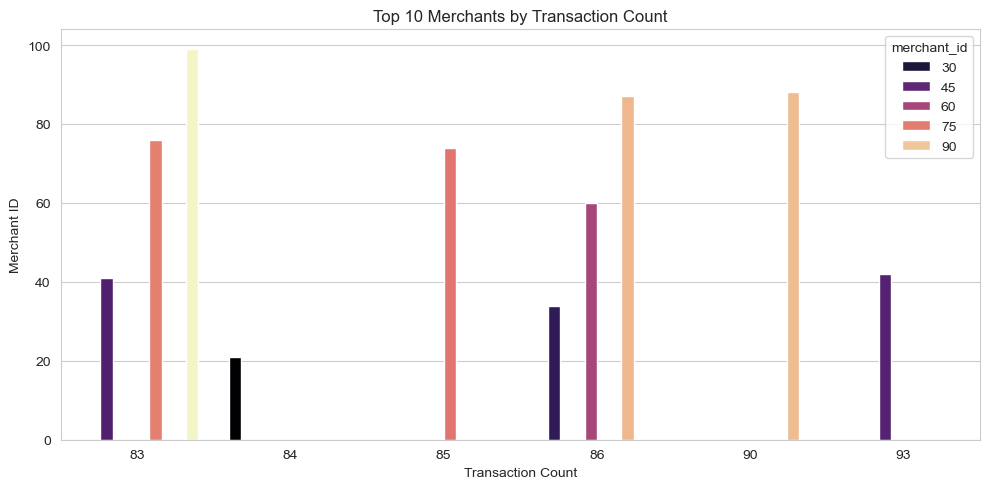

In [48]:
# Top merchants by transaction volume (count)
if "merchant_id" in df_completed.columns:
    top_merchants = (
        df_completed.groupby("merchant_id")
        .agg(tx_count=("transaction_id", "size"), total_value=("amount", "sum"))
        .sort_values("tx_count", ascending=False)
        .reset_index()
        .head(10)
    )
    display(top_merchants)

    plt.figure()
    sns.barplot(data=top_merchants, x="tx_count", y=top_merchants["merchant_id"], hue=top_merchants["merchant_id"], palette="magma")
    plt.title("Top 10 Merchants by Transaction Count")
    plt.xlabel("Transaction Count")
    plt.ylabel("Merchant ID")
    plt.tight_layout()
    plt.show()
else:
    print("No `merchant_id` column found; skipping top merchants.")

,transaction_id,customer_id,merchant_id,amount,fraud_flag
transaction_id,1.000000,-0.001147,-0.011265,0.009365,0.015227
customer_id,-0.001147,1.000000,0.025298,0.000929,0.007776
merchant_id,-0.011265,0.025298,1.000000,-0.004456,-0.008014
amount,0.009365,0.000929,-0.004456,1.000000,0.239576
fraud_flag,0.015227,0.007776,-0.008014,0.239576,1.000000


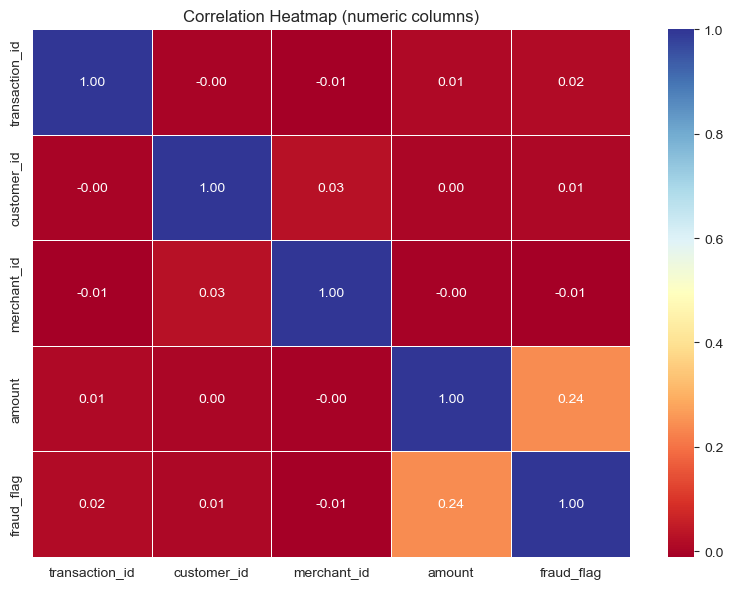

In [49]:
# Correlation heatmap for numeric columns (includes amount and fraud_flag)
# Build numeric DataFrame and map boolean fraud_flag to int if present
num_df = transactions.select_dtypes(include=["number"]).copy()
if "fraud_flag" in transactions.columns:
    if transactions["fraud_flag"].dtype == "bool":
        num_df["fraud_flag"] = transactions["fraud_flag"].astype(int)
    elif transactions["fraud_flag"].dtype == "object":
        num_df["fraud_flag"] = transactions["fraud_flag"].map({True:1, False:0})

if num_df.shape[1] >= 2:
    corr = num_df.corr()
    display(corr)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu", linewidths=.5)
    plt.title("Correlation Heatmap (numeric columns)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")

In [50]:
#Short business insights (printable)
print("Quick Insights:")
print("- Check months with large spikes in count/value for seasonality or campaigns.")
if "fraud_flag" in transactions.columns:
    print("- Look for payment methods or merchants linked with higher fraud rates.")
print("- Top customers and merchants indicate retention and partnership opportunities.")

Quick Insights:
- Check months with large spikes in count/value for seasonality or campaigns.
- Look for payment methods or merchants linked with higher fraud rates.
- Top customers and merchants indicate retention and partnership opportunities.
